## Sx, Sy, Sz expectation value for different unraveling Analysis

In [1]:
%matplotlib ipympl
from IPython.display import Image, display
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider
import matplotlib.ticker as ticker
import numba
from numba import njit, prange
import pickle
import os

## Configurazione Globale
Modifica qui i parametri per controllare quale dataset importare, plottare e salvare.

In [6]:
# ============================================================
# CONFIGURAZIONE GLOBALE
# Cambia MODE per switchare tra i due dataset:
#   'normal'       → results_intermediate.pkl
#   'close_to_90'  → results_close_to_90_deg.pkl
# ============================================================

MODE = 'close_to_90'   # <-- cambia qui: 'normal' oppure 'close_to_90'

# --- Paths ---
input_path = "../Results/Data/"
path_imm   = '/home/francesco/Collisional_Methods/Results/Plot/Probability/Sx_Sy_Sz'

# --- Mapping automatico in base a MODE ---
_cfg = {
    'normal': {
        'input_file':         os.path.join(input_path, "results_intermediate.pkl"),
        'save_sxyz_normal':   os.path.join(path_imm, "Sxyz_distributions.png"),
        'save_sxyz_squared':  os.path.join(path_imm, "Sxyz_square_distributions.png"),
        'save_sz_square':     os.path.join(path_imm, "Sz_square_distribution_intermediate.png"),
        'save_sz':            os.path.join(path_imm, "Sz_distribution_intermediate.png"),
        'save_variance':      os.path.join(path_imm, "Sz_Variance.png"),
        'save_variance_hist': os.path.join(path_imm, "Sz_Variance_Histogram.png"),
        'thetas_deg':         [90, 60, 45, 30, 0],
    },
    'close_to_90': {
        'input_file':         os.path.join(input_path, "results_close_to_90_deg.pkl"),
        'save_sxyz_normal':   os.path.join(path_imm, "Sxyz_distributions_close_to_90_deg.png"),
        'save_sxyz_squared':  os.path.join(path_imm, "Sxyz_square_distributions_close_to_90_deg.png"),
        'save_sz_square':     os.path.join(path_imm, "Sz_square_distribution_close_to_90_deg.png"),
        'save_sz':            os.path.join(path_imm, "Sz_distribution_close_to_90_deg.png"),
        'save_variance':      os.path.join(path_imm, "Sz_Variance_close_to_90_deg.png"),
        'save_variance_hist': os.path.join(path_imm, "Sz_Variance_Histogram_close_to_90_deg.png"),
        'thetas_deg':         [90, 89.9, 89.5, 89, 88.5, 88],
    },
}

cfg = _cfg[MODE]

# --- Parametri fisici ---
dt       = 0.01
N_traj   = 10000
site_idx = 0   # 0 per Qubit 1, 1 per Qubit 2

# --- Caricamento dati ---
with open(cfg['input_file'], 'rb') as f:
    results = pickle.load(f)

print(f"MODE    : {MODE}")
print(f"File    : {cfg['input_file']}")
print(f"Theta   : {[f'{np.degrees(t):.3f}°' for t in results.keys()]}")

MODE    : close_to_90
File    : ../Results/Data/results_close_to_90_deg.pkl
Theta   : ['90.000°', '89.900°', '89.500°', '89.000°', '88.500°', '88.000°']


## Sx, Sy, Sz — Istogrammi (valori normali e quadratici)

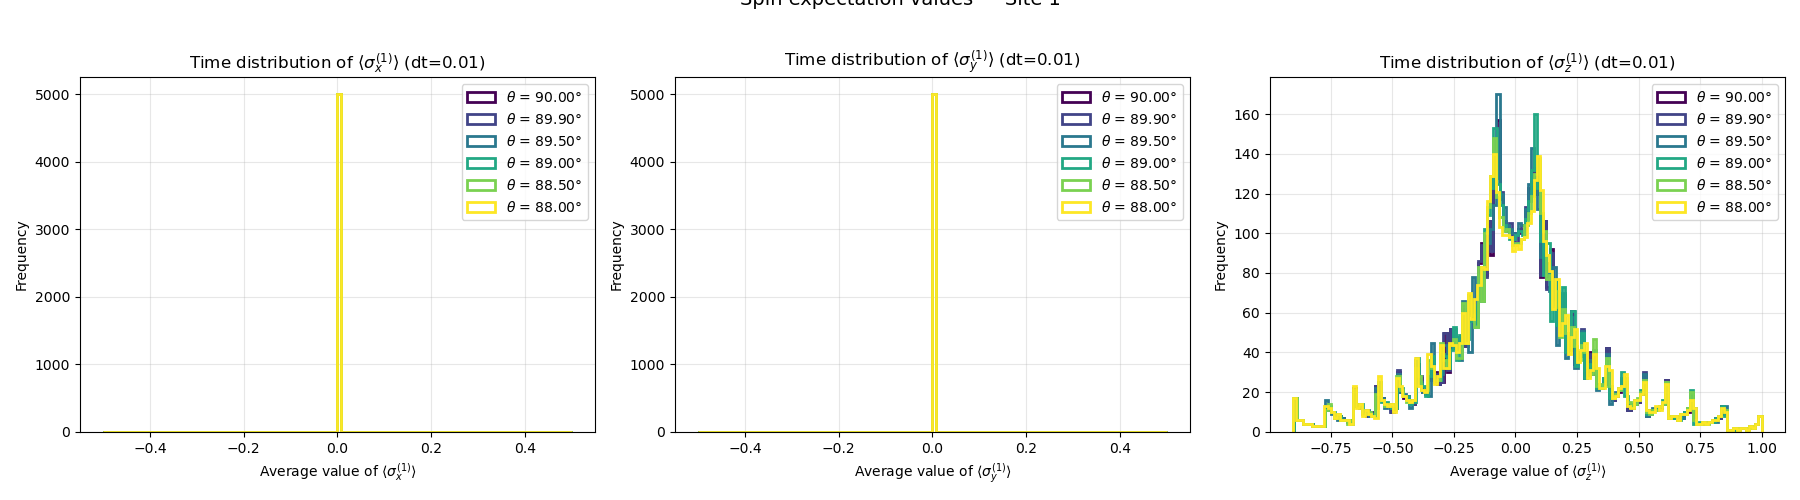

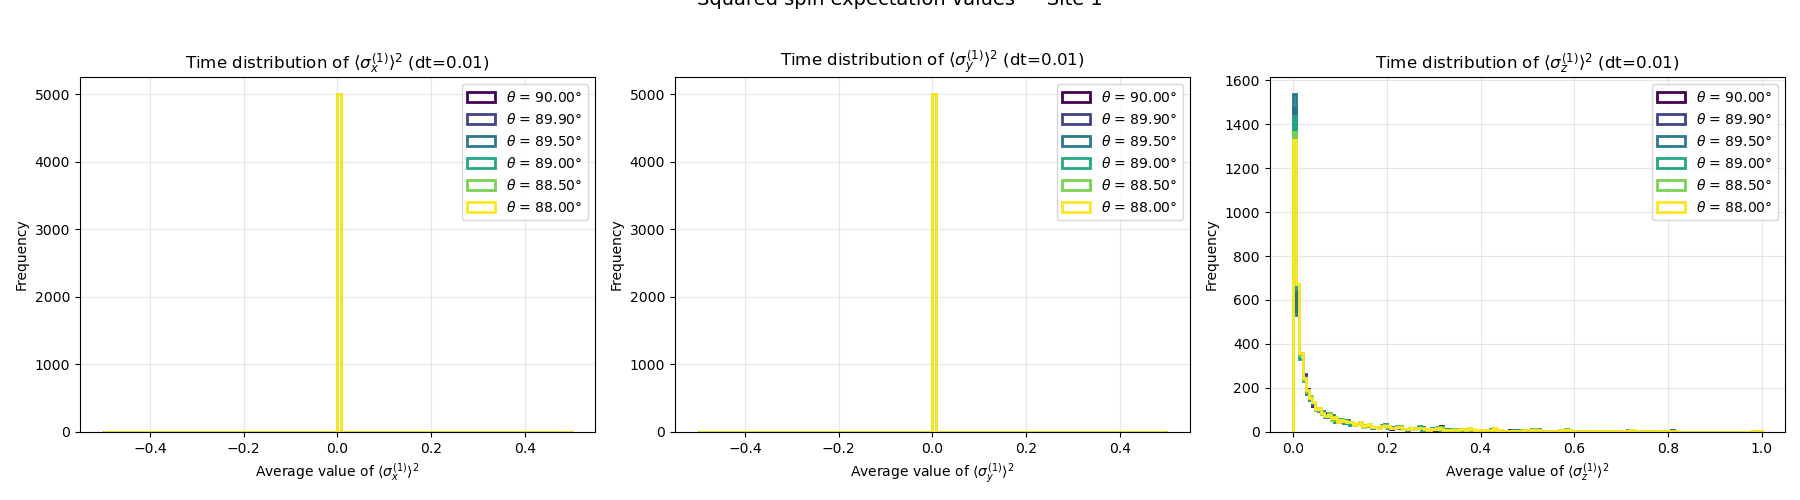

In [7]:
# --------------------------
# Plot Histograms (Subplots) - Normal and Squared Values
# --------------------------
colors = plt.cm.viridis(np.linspace(0, 1, len(results.keys())))

all_data = {}

for idx, theta_val in enumerate(results.keys()):
    theta_deg = np.degrees(theta_val)
    try:
        data_wf = results[theta_val][dt][N_traj]['trajectory_wf']
        sx_avg = data_wf['Sx_avg'][site_idx, :]
        sy_avg = data_wf['Sy_avg'][site_idx, :]
        sz_avg = data_wf['Sz_avg'][site_idx, :]
    except KeyError:
        continue

    all_data[theta_val] = {
        'theta_deg': theta_deg,
        'sx': sx_avg, 'sy': sy_avg, 'sz': sz_avg,
        'sx2': sx_avg**2, 'sy2': sy_avg**2, 'sz2': sz_avg**2,
        'color': colors[idx]
    }

# --- Figure 1: Normal values ---
fig_normal, axes_normal = plt.subplots(1, 3, figsize=(18, 5))

titles_normal = [
    f'$\\langle \\sigma_x^{{({site_idx+1})}} \\rangle$',
    f'$\\langle \\sigma_y^{{({site_idx+1})}} \\rangle$',
    f'$\\langle \\sigma_z^{{({site_idx+1})}} \\rangle$'
]
keys_normal = ['sx', 'sy', 'sz']

for d in all_data.values():
    for ax, key in zip(axes_normal, keys_normal):
        ax.hist(d[key], bins=150, histtype='step', linewidth=2,
                color=d['color'], label=f'$\\theta$ = {d["theta_deg"]:.2f}°')

for i, ax in enumerate(axes_normal):
    ax.set_title(f'Time distribution of {titles_normal[i]} (dt={dt})')
    ax.set_xlabel(f'Average value of {titles_normal[i]}')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig_normal.suptitle(f'Spin expectation values — Site {site_idx+1}', fontsize=14, y=1.02)
plt.tight_layout()
#fig_normal.savefig(cfg['save_sxyz_normal'], dpi=300)
plt.show()

# --- Figure 2: Squared values ---
fig_squared, axes_squared = plt.subplots(1, 3, figsize=(18, 5))

titles_squared = [
    f'$\\langle \\sigma_x^{{({site_idx+1})}} \\rangle^2$',
    f'$\\langle \\sigma_y^{{({site_idx+1})}} \\rangle^2$',
    f'$\\langle \\sigma_z^{{({site_idx+1})}} \\rangle^2$'
]
keys_squared = ['sx2', 'sy2', 'sz2']

for d in all_data.values():
    for ax, key in zip(axes_squared, keys_squared):
        ax.hist(d[key], bins=150, histtype='step', linewidth=2,
                color=d['color'], label=f'$\\theta$ = {d["theta_deg"]:.2f}°')

for i, ax in enumerate(axes_squared):
    ax.set_title(f'Time distribution of {titles_squared[i]} (dt={dt})')
    ax.set_xlabel(f'Average value of {titles_squared[i]}')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig_squared.suptitle(f'Squared spin expectation values — Site {site_idx+1}', fontsize=14, y=1.02)
plt.tight_layout()
#fig_squared.savefig(cfg['save_sxyz_squared'], dpi=300)
plt.show()

Results for Sx and Sy should be correct, check the old bloch sphere build up in the results for the single site, it has a dynamic of oscillation only along the z axis

## Only Sz

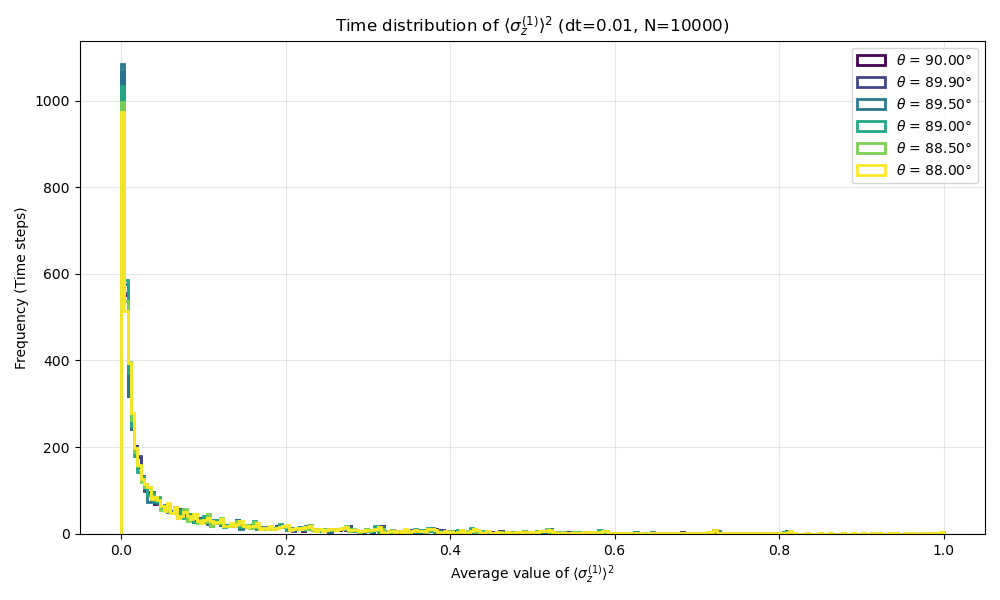

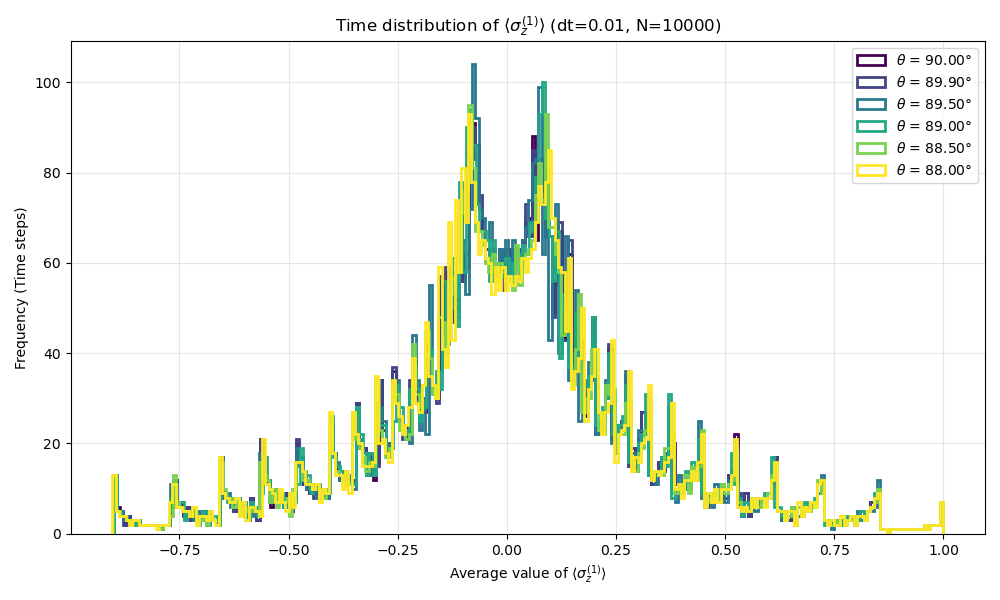

In [8]:
# ------------------
# Plot: <Sz>^2
# ------------------
fig50, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(results.keys())))

for idx, theta_val in enumerate(results.keys()):
    theta_deg = np.degrees(theta_val)
    try:
        data_wf      = results[theta_val][dt][N_traj]['trajectory_wf']
        sz_avg_square = data_wf['Sz_avg_square'][site_idx, :]
    except KeyError:
        print(f"Dati mancanti per theta={theta_deg}°, salto.")
        continue
    ax.hist(sz_avg_square, bins=250, histtype='step', linewidth=2,
            color=colors[idx], label=f'$\\theta$ = {theta_deg:.2f}°')

ax.set_title(f'Time distribution of $\\langle \\sigma_z^{{({site_idx+1})}} \\rangle^2$ (dt={dt}, N={N_traj})')
ax.set_xlabel(f'Average value of $\\langle \\sigma_z^{{({site_idx+1})}} \\rangle^2$')
ax.set_ylabel('Frequency (Time steps)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
#fig50.savefig(cfg['save_sz_square'], dpi=300, bbox_inches='tight')
plt.show()

# ------------------
# Plot: <Sz>
# ------------------
fig51, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(results.keys())))

for idx, theta_val in enumerate(results.keys()):
    theta_deg = np.degrees(theta_val)
    try:
        data_wf = results[theta_val][dt][N_traj]['trajectory_wf']
        sz_avg  = data_wf['Sz_avg'][site_idx, :]
    except KeyError:
        print(f"Dati mancanti per theta={theta_deg}°, salto.")
        continue
    ax.hist(sz_avg, bins=250, histtype='step', linewidth=2,
            color=colors[idx], label=f'$\\theta$ = {theta_deg:.2f}°')

ax.set_title(f'Time distribution of $\\langle \\sigma_z^{{({site_idx+1})}} \\rangle$ (dt={dt}, N={N_traj})')
ax.set_xlabel(f'Average value of $\\langle \\sigma_z^{{({site_idx+1})}} \\rangle$')
ax.set_ylabel('Frequency (Time steps)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
#fig51.savefig(cfg['save_sz'], dpi=300, bbox_inches='tight')
plt.show()

## Variance

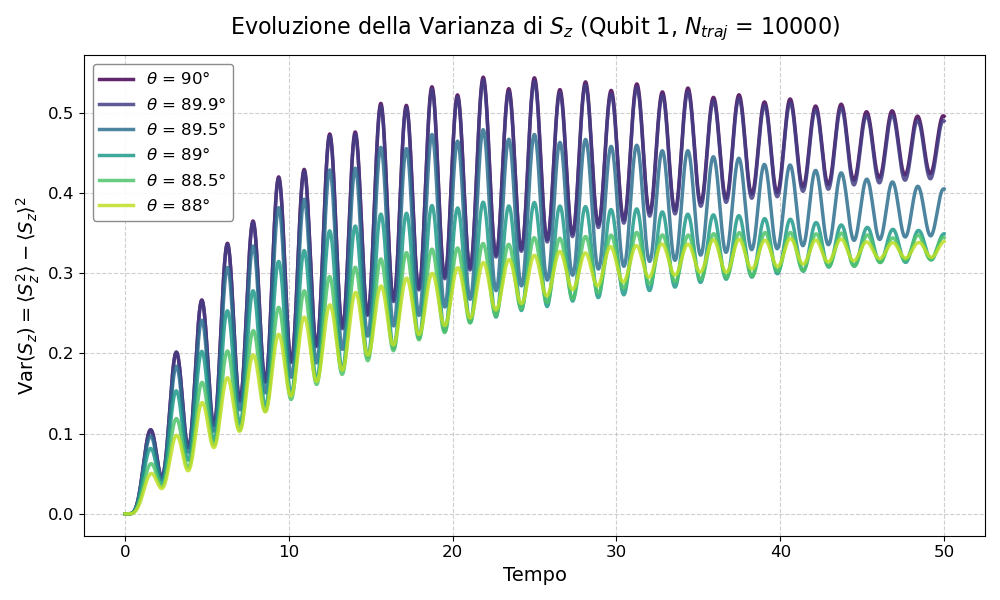

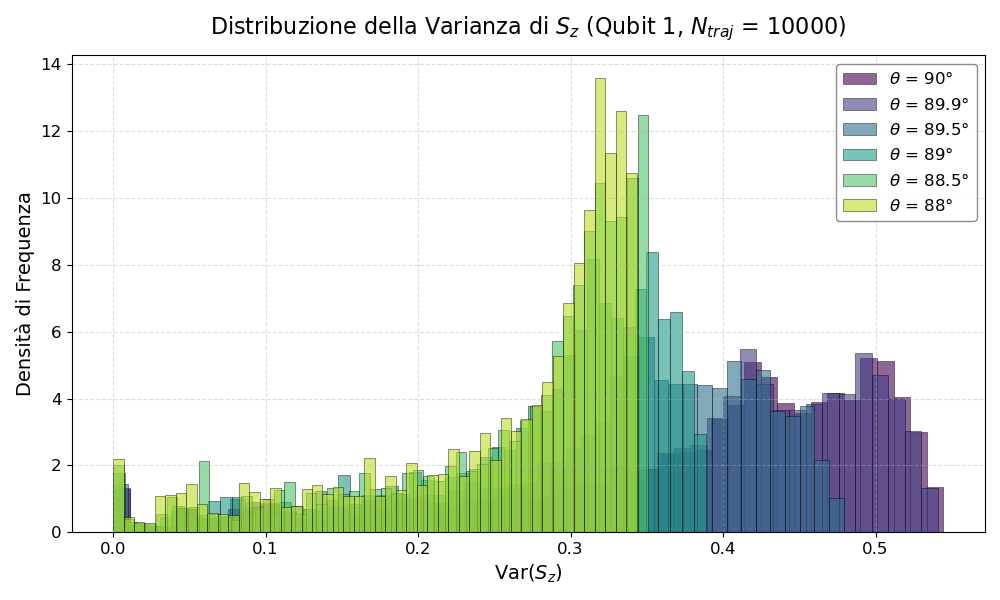

In [9]:
# ------------------
# Plot: Varianza di Sz nel tempo
# ------------------
plt.figure(figsize=(10, 6))
thetas_deg = cfg['thetas_deg']
colors = plt.cm.viridis(np.linspace(0, 0.9, len(thetas_deg)))

for idx, deg in enumerate(thetas_deg):
    theta_val = np.radians(deg)
    matching  = [t for t in results.keys() if np.isclose(t, theta_val, atol=1e-4)]
    if matching:
        key           = matching[0]
        data_wf       = results[key][dt][N_traj]['trajectory_wf']
        times         = results[key][dt][N_traj]['parameters']['times']
        sz_avg        = data_wf['Sz_avg'][site_idx, :]
        sz_square_avg = data_wf['Sz_square_avg'][site_idx, :]
        variance      = sz_square_avg - sz_avg**2
        plt.plot(times, variance, label=f'$\\theta$ = {deg}°', color=colors[idx], linewidth=2.5, alpha=0.85)
    else:
        print(f"Attenzione: dati per theta = {deg}° non trovati.")

plt.title(f'Evoluzione della Varianza di $S_z$ (Qubit {site_idx+1}, $N_{{traj}}$ = {N_traj})', fontsize=16, pad=15)
plt.xlabel('Tempo', fontsize=14)
plt.ylabel(r'$\operatorname{Var}(S_z) = \langle S_z^2 \rangle - \langle S_z \rangle^2$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12, loc='best', framealpha=0.9, edgecolor='gray')
plt.tight_layout()
#plt.savefig(cfg['save_variance'], dpi=300, bbox_inches='tight')
plt.show()

# ------------------
# Plot: Istogramma varianza di Sz
# ------------------
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(thetas_deg)))
n_bins = 50

for idx, deg in enumerate(thetas_deg):
    theta_val = np.radians(deg)
    matching  = [t for t in results.keys() if np.isclose(t, theta_val, atol=1e-4)]
    if matching:
        key           = matching[0]
        data_wf       = results[key][dt][N_traj]['trajectory_wf']
        sz_avg        = data_wf['Sz_avg'][site_idx, :]
        sz_square_avg = data_wf['Sz_square_avg'][site_idx, :]
        variance      = sz_square_avg - sz_avg**2
        plt.hist(variance, bins=n_bins, color=colors[idx], alpha=0.6,
                 label=f'$\\theta$ = {deg}°', edgecolor='black', linewidth=0.5, density=True)
    else:
        print(f"Attenzione: dati per theta = {deg}° non trovati.")

plt.title(f'Distribuzione della Varianza di $S_z$ (Qubit {site_idx+1}, $N_{{traj}}$ = {N_traj})', fontsize=16, pad=15)
plt.xlabel(r'$\operatorname{Var}(S_z)$', fontsize=14)
plt.ylabel('Densità di Frequenza', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12, loc='best', framealpha=0.9, edgecolor='gray')
plt.tight_layout()
#plt.savefig(cfg['save_variance_hist'], dpi=300, bbox_inches='tight')
plt.show()